# Column Generation for Optical Network RWA
Equivalent Python implementation of main_CG.m

In [1]:
# !pip install scipy
import numpy as np
from scipy.optimize import linprog, milp, LinearConstraint, Bounds
import matplotlib.pyplot as plt

## Loading Parameters

In [2]:
maxWavelengths = 8
maxTransceivers = 1000000

normalized_demand_matrix = np.array([
    [0, 0, 0, 1/3],
    [0, 0, 1/3, 1/3],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
])

# Path Capacity
Capacity124 = 100
Capacity134 = 100
Capacity14 = 100
Capacity243 = 100
Capacity213 = 100
Capacity2143 = 50
Capacity24 = 250
Capacity2134 = 100
Capacity214 = 50

## Initial Configurations

In [3]:
# Config1: 'p124'
T1 = np.array([100, 0, 0])
isTransActive1 = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0])
noTrans1 = np.sum(isTransActive1)

# Config2: 'p243'
T2 = np.array([0, 100, 0])
isTransActive2 = np.array([0, 0, 0, 1, 0, 0, 0, 0, 0])
noTrans2 = np.sum(isTransActive2)

# Config3: 'p24'
T3 = np.array([0, 0, 250])
isTransActive3 = np.array([0, 0, 0, 0, 0, 0, 1, 0, 0])
noTrans3 = np.sum(isTransActive3)

tranCapacityArray = np.column_stack([T1, T2, T3])
isTransActiveArray = np.column_stack([isTransActive1, isTransActive2, isTransActive3])
NumTransArray = np.array([noTrans1, noTrans2, noTrans3])

## Solver Functions

In [4]:
def solve_RMP(tranCapacityArray, NumTransArray, normalized_demand_matrix, maxWavelengths, maxTransceivers):
    """Solve Restricted Master Problem (RMP)"""
    n_configs = tranCapacityArray.shape[1]
    n_vars = n_configs + 1
    
    c = np.zeros(n_vars)
    c[-1] = -1
    
    A_ub = []
    b_ub = []
    
    demands = [normalized_demand_matrix[0, 3], normalized_demand_matrix[1, 2], normalized_demand_matrix[1, 3]]
    
    for i, d in enumerate(demands):
        row = np.zeros(n_vars)
        row[:n_configs] = -tranCapacityArray[i, :]
        row[-1] = d
        A_ub.append(row)
        b_ub.append(0)
    
    row = np.zeros(n_vars)
    row[:n_configs] = 1
    A_ub.append(row)
    b_ub.append(maxWavelengths)
    
    row = np.zeros(n_vars)
    row[:n_configs] = NumTransArray
    A_ub.append(row)
    b_ub.append(maxTransceivers)
    
    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)
    bounds = [(0, None) for _ in range(n_vars)]
    
    result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    
    if result.success:
        duals = -result.ineqlin.marginals if hasattr(result, 'ineqlin') else np.zeros(len(b_ub))
        return {
            'z': result.x[:n_configs],
            'TN': result.x[-1],
            'lambda_demand14': duals[0],
            'lambda_demand23': duals[1],
            'lambda_demand24': duals[2],
            'lambda_wavelength': duals[3],
            'lambda_transceiver': duals[4],
            'success': True
        }
    return {'success': False}

In [5]:
def solve_pricing(lambda_demand14, lambda_demand23, lambda_demand24, lambda_wavelength, lambda_transceiver):
    """Solve Pricing subproblem using MILP"""
    n_vars = 13
    capacities = np.array([Capacity124, Capacity134, Capacity14, Capacity243, Capacity213, Capacity2143, Capacity24, Capacity2134, Capacity214])
    
    c = np.zeros(n_vars)
    c[9] = -lambda_demand14
    c[10] = -lambda_demand23
    c[11] = -lambda_demand24
    c[12] = lambda_transceiver
    
    A_eq = []
    b_eq = []
    
    # T('14')
    row = np.zeros(n_vars)
    row[0], row[1], row[2] = capacities[0], capacities[1], capacities[2]
    row[9] = -1
    A_eq.append(row); b_eq.append(0)
    
    # T('23')
    row = np.zeros(n_vars)
    row[3], row[4], row[5] = capacities[3], capacities[4], capacities[5]
    row[10] = -1
    A_eq.append(row); b_eq.append(0)
    
    # T('24')
    row = np.zeros(n_vars)
    row[6], row[7], row[8] = capacities[6], capacities[7], capacities[8]
    row[11] = -1
    A_eq.append(row); b_eq.append(0)
    
    # sum(x) == a
    row = np.zeros(n_vars)
    row[:9] = 1; row[12] = -1
    A_eq.append(row); b_eq.append(0)
    
    A_eq = np.array(A_eq); b_eq = np.array(b_eq)
    
    # Wavelength non-overlapping constraints
    A_ub = []
    b_ub = []
    
    constraints_def = [
        ([0], 1),                    # LINK12
        ([1, 4, 7], 1),              # LINK13
        ([2, 5, 8], 1),              # LINK14
        ([0, 3, 6], 1),              # LINK24
        ([1, 7], 1),                 # LINK34
        ([4, 5, 7, 8], 1),           # LINK21
        ([3, 5], 1),                 # LINK43
    ]
    
    for indices, bound in constraints_def:
        row = np.zeros(n_vars)
        for idx in indices:
            row[idx] = 1
        A_ub.append(row)
        b_ub.append(bound)
    
    A_ub = np.array(A_ub); b_ub = np.array(b_ub)
    
    bounds = Bounds(lb=np.zeros(n_vars), ub=np.array([1]*9 + [np.inf]*3 + [np.inf]))
    integrality = np.array([1]*9 + [0]*3 + [1])
    
    constraints = [LinearConstraint(A_ub, -np.inf, b_ub), LinearConstraint(A_eq, b_eq, b_eq)]
    result = milp(c, constraints=constraints, bounds=bounds, integrality=integrality)
    
    if result.success:
        return {
            'x': result.x[:9],
            'T': result.x[9:12],
            'a': result.x[12],
            'reduced_cost': -result.fun - lambda_wavelength,
            'success': True
        }
    return {'success': False, 'reduced_cost': -np.inf}

In [6]:
def solve_RMP_integer(tranCapacityArray, NumTransArray, normalized_demand_matrix, maxWavelengths, maxTransceivers):
    """Solve RMP as integer program for final solution"""
    n_configs = tranCapacityArray.shape[1]
    n_vars = n_configs + 1
    
    c = np.zeros(n_vars)
    c[-1] = -1
    
    A_ub = []
    b_ub = []
    demands = [normalized_demand_matrix[0, 3], normalized_demand_matrix[1, 2], normalized_demand_matrix[1, 3]]
    
    for i, d in enumerate(demands):
        row = np.zeros(n_vars)
        row[:n_configs] = -tranCapacityArray[i, :]
        row[-1] = d
        A_ub.append(row)
        b_ub.append(0)
    
    row = np.zeros(n_vars)
    row[:n_configs] = 1
    A_ub.append(row)
    b_ub.append(maxWavelengths)
    
    row = np.zeros(n_vars)
    row[:n_configs] = NumTransArray
    A_ub.append(row)
    b_ub.append(maxTransceivers)
    
    A_ub = np.array(A_ub); b_ub = np.array(b_ub)
    bounds = Bounds(lb=np.zeros(n_vars), ub=np.full(n_vars, np.inf))
    integrality = np.array([1]*n_configs + [0])
    
    constraints = [LinearConstraint(A_ub, -np.inf, b_ub)]
    result = milp(c, constraints=constraints, bounds=bounds, integrality=integrality)
    
    if result.success:
        return {'z': result.x[:n_configs], 'TN': result.x[-1], 'success': True}
    return {'success': False}

## Column Generation Loop

In [7]:
print("=" * 50)
print("Column Generation for RWA Problem")
print("=" * 50)

rmp_result = solve_RMP(tranCapacityArray, NumTransArray, normalized_demand_matrix, maxWavelengths, maxTransceivers)
print(f" Maximal network throughput {rmp_result['TN']:.6g} [Gbps]")

pricing_result = solve_pricing(
    rmp_result['lambda_demand14'], rmp_result['lambda_demand23'],
    rmp_result['lambda_demand24'], rmp_result['lambda_wavelength'],
    rmp_result['lambda_transceiver']
)

reducedCost = pricing_result['reduced_cost']
iteration = 1

while reducedCost >= 1e-6:
    iteration += 1
    
    tranCapacityArray = np.column_stack([tranCapacityArray, pricing_result['T']])
    NumTransArray = np.append(NumTransArray, pricing_result['a'])
    isTransActiveArray = np.column_stack([isTransActiveArray, pricing_result['x']])
    
    rmp_result = solve_RMP(tranCapacityArray, NumTransArray, normalized_demand_matrix, maxWavelengths, maxTransceivers)
    if not rmp_result['success']:
        print("RMP failed!"); break
    
    print(f" Maximal network throughput {rmp_result['TN']:.6g} [Gbps]")
    
    pricing_result = solve_pricing(
        rmp_result['lambda_demand14'], rmp_result['lambda_demand23'],
        rmp_result['lambda_demand24'], rmp_result['lambda_wavelength'],
        rmp_result['lambda_transceiver']
    )
    if not pricing_result['success']:
        print("Pricing failed!"); break
    
    reducedCost = pricing_result['reduced_cost']

print(f"\nConverged after {iteration} iterations")

Column Generation for RWA Problem
 Maximal network throughput 1000 [Gbps]
 Maximal network throughput 1384.62 [Gbps]
 Maximal network throughput 2400 [Gbps]
 Maximal network throughput 2666.67 [Gbps]
 Maximal network throughput 3000 [Gbps]

Converged after 5 iterations


## Final Integer Solution & Visualization

In [8]:
pathIdx = {'p124': 0, 'p134': 1, 'p14': 2, 'p243': 3, 'p213': 4, 'p2143': 5, 'p24': 6, 'p2134': 7, 'p214': 8}

int_result = solve_RMP_integer(tranCapacityArray, NumTransArray, normalized_demand_matrix, maxWavelengths, maxTransceivers)

print("Optimal solutions:")
z_int = int_result['z']
for i in range(len(z_int)):
    nConfigs = int(round(z_int[i]))
    if nConfigs >= 1:
        active_paths = [p for p, idx in pathIdx.items() if isTransActiveArray[idx, i] > 0.5]
        print(f" configurations {{{','.join(active_paths)}}} in {nConfigs} times")

Optimal solutions:
 configurations {p124,p134,p14} in 1 times
 configurations {p14,p213,p24} in 4 times
 configurations {p14,p243,p213} in 3 times


In [9]:
# Wavelength assignment
link12 = np.zeros(maxWavelengths)
link13 = np.zeros(maxWavelengths)
link14 = np.zeros(maxWavelengths)
link24 = np.zeros(maxWavelengths)
link34 = np.zeros(maxWavelengths)
link21 = np.zeros(maxWavelengths)
link43 = np.zeros(maxWavelengths)

wStart = 0
for i in range(len(z_int)):
    nConfigs = int(round(z_int[i]))
    if nConfigs >= 1:
        wEnd = wStart + nConfigs
        link12[wStart:wEnd] = isTransActiveArray[pathIdx['p124'], i]
        link13[wStart:wEnd] = isTransActiveArray[pathIdx['p134'], i] + isTransActiveArray[pathIdx['p213'], i] + isTransActiveArray[pathIdx['p2134'], i]
        link14[wStart:wEnd] = isTransActiveArray[pathIdx['p14'], i] + isTransActiveArray[pathIdx['p2143'], i] + isTransActiveArray[pathIdx['p214'], i]
        link24[wStart:wEnd] = isTransActiveArray[pathIdx['p124'], i] + isTransActiveArray[pathIdx['p243'], i] + isTransActiveArray[pathIdx['p24'], i]
        link34[wStart:wEnd] = isTransActiveArray[pathIdx['p134'], i] + isTransActiveArray[pathIdx['p2134'], i]
        link21[wStart:wEnd] = isTransActiveArray[pathIdx['p213'], i] + isTransActiveArray[pathIdx['p2143'], i] + isTransActiveArray[pathIdx['p2134'], i] + isTransActiveArray[pathIdx['p214'], i]
        link43[wStart:wEnd] = isTransActiveArray[pathIdx['p243'], i] + isTransActiveArray[pathIdx['p2143'], i]
        wStart = wEnd

networkSpectrum = np.array([link12, link13, link14, link24, link34, link21, link43])

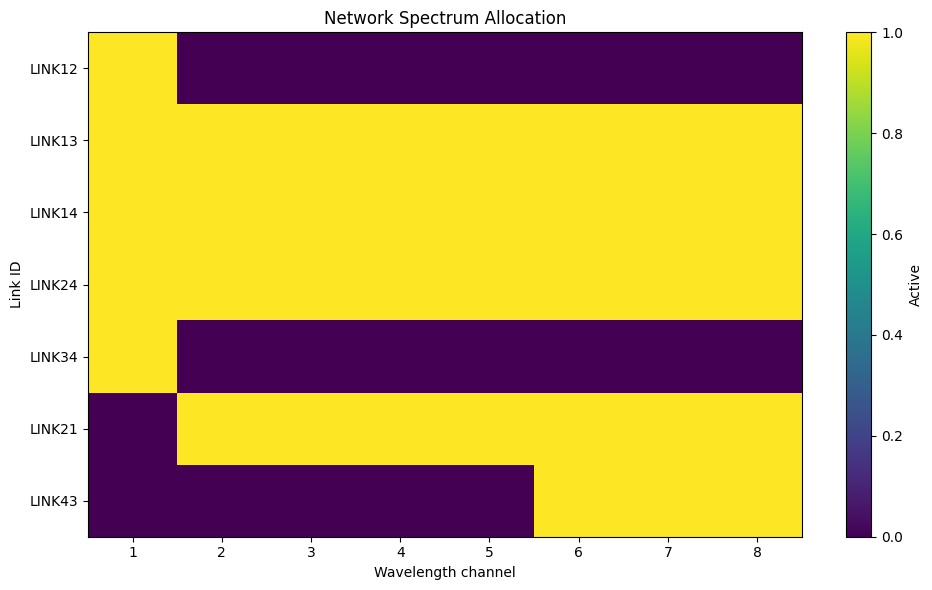


Final network throughput: 3000 [Gbps]


In [10]:
plt.figure(figsize=(10, 6))
plt.imshow(networkSpectrum, aspect='auto', cmap='viridis')
plt.colorbar(label='Active')
plt.xlabel("Wavelength channel")
plt.ylabel("Link ID")
plt.xticks(range(maxWavelengths), range(1, maxWavelengths + 1))
plt.yticks(range(7), ['LINK12', 'LINK13', 'LINK14', 'LINK24', 'LINK34', 'LINK21', 'LINK43'])
plt.title("Network Spectrum Allocation")
plt.tight_layout()
plt.show()

print(f"\nFinal network throughput: {int_result['TN']:.6g} [Gbps]")